# Pairs / Statistical Arbitrage / Cointegration Case Study

## Questions

1. Screen a small universe for candidate pairs
2. Diagnose cointegration rather than relying on raw correlation only
3. Build a simple spread-zscore strategy
4. Conclude on significance and robustness

In [19]:
import warnings
warnings.filterwarnings("ignore")

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm

from IPython.display import display
from statsmodels.tsa.stattools import coint, adfuller
from statsmodels.graphics.tsaplots import plot_acf

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

## 1. Load data, audit, and train/holdout split

In [20]:
df_raw = pd.read_csv("9_pairs_stat_arb_cointegration_case.csv", parse_dates=["date"])
print("Shape:", df_raw.shape)
print("Duplicates:", int(df_raw.duplicated().sum()))
print("Date range:", df_raw["date"].min().date(), "to", df_raw["date"].max().date())
print("Assets:", sorted(df_raw["asset"].unique()))
display(df_raw.isna().sum().to_frame("missing").T)

Shape: (17601, 4)
Duplicates: 1
Date range: 2014-01-02 to 2022-06-08
Assets: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']


,date,asset,close,volume
missing,0,0,0,0


In [21]:
df = df_raw.sort_values(["date", "asset"]).drop_duplicates().reset_index(drop=True).copy()
prices = df.pivot(index="date", columns="asset", values="close").sort_index()
volume = df.pivot(index="date", columns="asset", values="volume").sort_index()

# --- Temporal split: 80% train / 20% holdout ---
# Set aside the holdout now — it will not be touched until section 6.
cut = int(len(prices) * 0.8)
train_prices = prices.iloc[:cut]
hold_prices = prices.iloc[cut:]
train_volume = volume.iloc[:cut]
logp = np.log(prices)
train_logp = logp.iloc[:cut]
train_returns = train_logp.diff().dropna()

print(f"Full dataset: {len(prices)} trading days, {prices.shape[1]} assets")
print(f"Train: {len(train_prices)} days ({train_prices.index[0].date()} to {train_prices.index[-1].date()})")
print(f"Holdout: {len(hold_prices)} days ({hold_prices.index[0].date()} to {hold_prices.index[-1].date()})")

Full dataset: 2200 trading days, 8 assets
Train: 1760 days (2014-01-02 to 2020-09-30)
Holdout: 440 days (2020-10-01 to 2022-06-08)


## 2. Exploratory data analysis (train only)

The goal of the EDA is to understand the co-movement structure across assets, identify which pairs might share a long-run equilibrium, and flag any liquidity or regime concerns before running formal cointegration tests.

### 2.1 Price levels and volatility

Normalized prices reveal whether assets share common trends — a necessary (but not sufficient) condition for cointegration. The rolling volatility helps identify regime shifts that could break cointegration relationships.

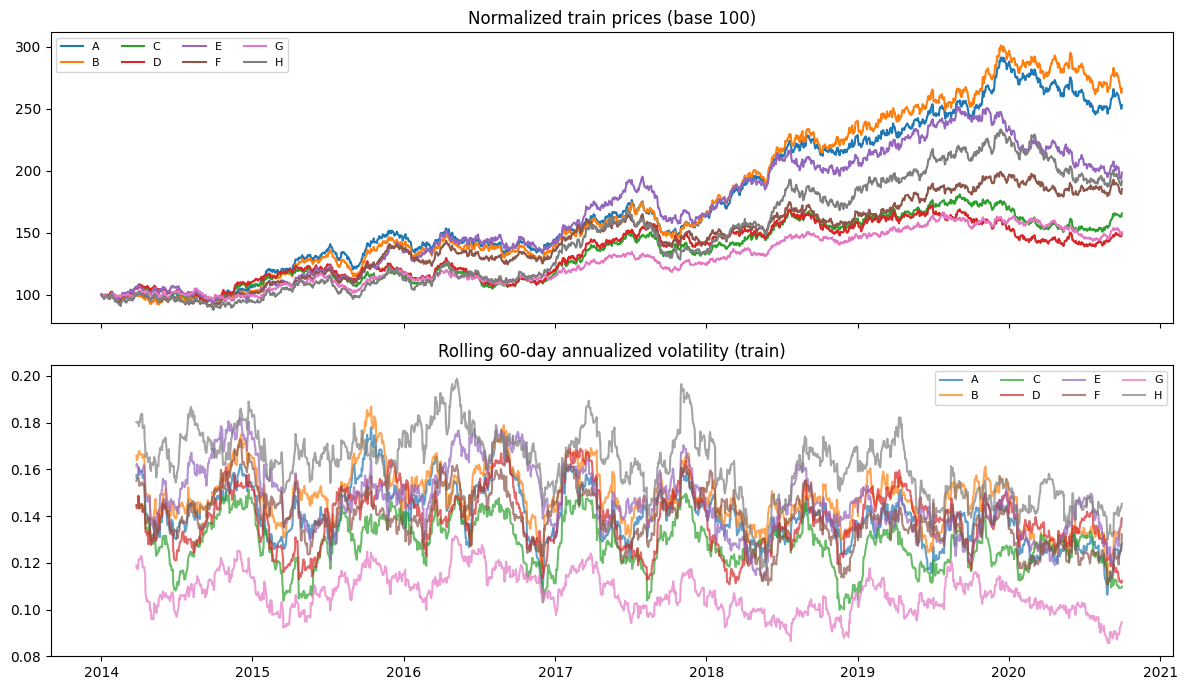

In [22]:
%matplotlib inline

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

normed = train_prices / train_prices.iloc[0] * 100
for col in normed.columns:
    axes[0].plot(normed.index, normed[col], label=col)
axes[0].legend(ncol=4, fontsize=8)
axes[0].set_title("Normalized train prices (base 100)")

roll_vol = train_returns.rolling(60).std() * np.sqrt(252)
for col in roll_vol.columns:
    axes[1].plot(roll_vol.index, roll_vol[col], label=col, alpha=0.7)
axes[1].legend(ncol=4, fontsize=8)
axes[1].set_title("Rolling 60-day annualized volatility (train)")
plt.tight_layout()
plt.show()

Several assets share a common upward trend through 2018–2019 (A, B, E, H all in the 120–180 range), followed by a sharp drawdown in early 2020 and a volatile recovery. G and H appear to co-move closely in both level and volatility, which makes them a natural pair candidate. The 2020 volatility spike is 3-4× the baseline for all assets — any cointegration relationship estimated across this period should be treated with caution.

### 2.2 Return correlation structure

High return correlation is necessary for a tradable pair (the spread has lower variance), but it is not sufficient — two assets can be highly correlated without being cointegrated if they share a common trend but no mean-reverting spread. The correlation matrix identifies candidates; the cointegration test (section 3) filters them.

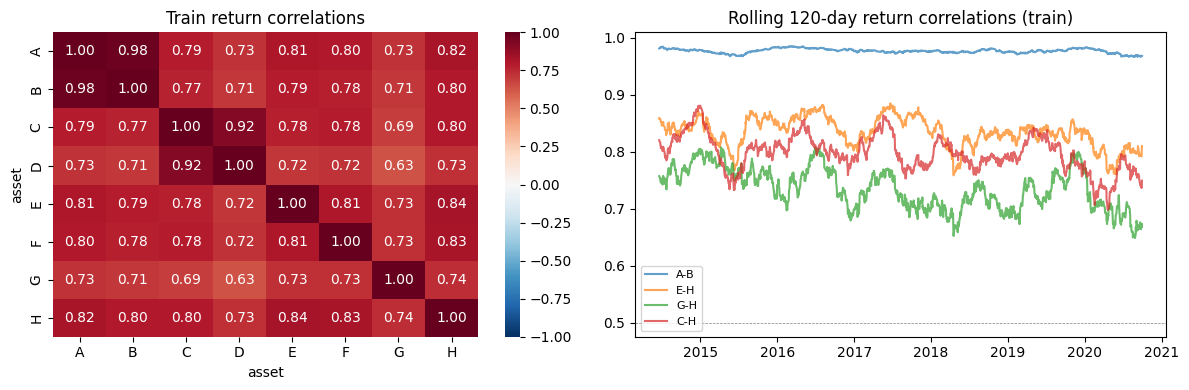

In [23]:
corr_matrix = train_returns.corr()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title("Train return correlations")

# Rolling 120-day correlation for visually co-moving pairs
top_pairs = [("A", "B"), ("E", "H"), ("G", "H"), ("C", "H")]
for a_, b_ in top_pairs:
    rc = train_returns[a_].rolling(120).corr(train_returns[b_])
    axes[1].plot(rc.index, rc, label=f"{a_}-{b_}", alpha=0.7)
axes[1].axhline(0.5, color="gray", linestyle="--", lw=0.5)
axes[1].legend(fontsize=8)
axes[1].set_title("Rolling 120-day return correlations (train)")
plt.tight_layout()
plt.show()

A-B stands out with a return correlation of 0.98 — almost perfect co-movement. But high correlation does not guarantee cointegration: if both assets drift in the same direction without a stable spread, there is no mean-reversion to trade. G-H (0.74), E-H (0.84), and C-H (0.80) are the next cluster.

The rolling correlation plot shows the temporal stability of these relationships. All four pairs exhibit some variation at the 120-day scale. The key takeaway is not which pair has the highest or most stable correlation, but rather that correlation alone is insufficient — the formal cointegration test in Section 3 will determine which pairs have a stationary spread.

### 2.3 Volume check

A cointegrated pair with an illiquid leg is not tradable. I check that volume is sufficient and stable across all assets.

asset,B,H,E,C,D,A,G,F
avg_daily_volume,1860680.0,1901155.0,2413558.0,3080910.0,3724674.0,4198804.0,4250682.0,4254730.0


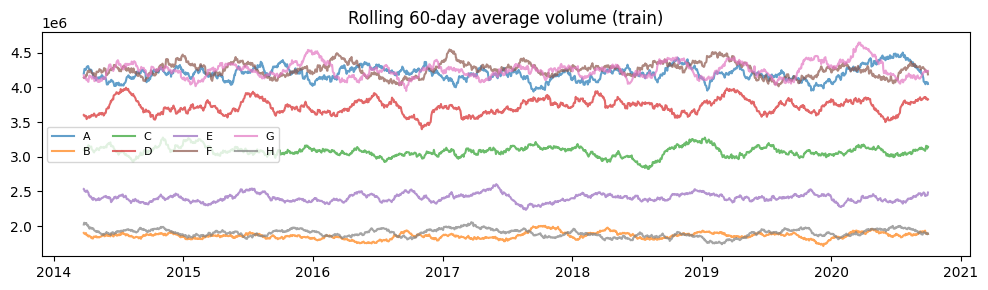

In [24]:
display(train_volume.mean().sort_values().to_frame("avg_daily_volume").T.round(0))

fig, ax = plt.subplots(figsize=(10, 3))
for col in train_volume.columns:
    ax.plot(train_volume.index, train_volume[col].rolling(60).mean(), label=col, alpha=0.7)
ax.legend(ncol=4, fontsize=8)
ax.set_title("Rolling 60-day average volume (train)")
plt.tight_layout()
plt.show()

All assets trade above 1.8M shares/day on average. B (1.86M) and H (1.90M) are the least liquid, while F (4.25M) and G (4.25M) are the most liquid. No asset has a problematic volume drop. G-H, our leading pair candidate from the correlation analysis, has average volumes of 4.25M (G) and 1.90M (H) — sufficient for a stat-arb strategy, though H's lower volume will be the binding constraint on position sizing.

## 3. Pair screening (train only)

I compute log-prices and log-returns on the training set for the formal screening. Log-prices are the natural input to the Engle-Granger cointegration test (which estimates a linear relationship between log-price levels), and log-returns are used for the correlation metric.

I screen all 28 pairs on two criteria:
1. **Engle-Granger cointegration p-value** — is the spread stationary?
2. **Return correlation** — do the assets move together?

With 28 pairs tested, Bonferroni sets the significance threshold at 0.05/28 ≈ 0.0018.

In [25]:
assets = list(train_prices.columns)
n_pairs = len(assets) * (len(assets) - 1) // 2
bonferroni_threshold = 0.05 / n_pairs

pairs = []
for i in range(len(assets)):
    for j in range(i + 1, len(assets)):
        a_, b_ = assets[i], assets[j]
        corr = train_returns[a_].corr(train_returns[b_])
        c_stat, pval, _ = coint(train_logp[a_], train_logp[b_])
        pairs.append({"pair": f"{a_}-{b_}", "corr_ret": round(corr, 3),
                       "coint_pval": round(pval, 4),
                       "bonferroni_sig": pval < bonferroni_threshold})

screen = pd.DataFrame(pairs).sort_values("coint_pval")
display(screen)
print(f"\nBonferroni threshold ({n_pairs} tests): {bonferroni_threshold:.4f}")
print(f"Pairs significant after Bonferroni: {screen['bonferroni_sig'].sum()}")

,pair,corr_ret,coint_pval,bonferroni_sig
27,G-H,0.737,0.0011,True
11,B-G,0.710,0.0487,False
5,A-G,0.725,0.0603,False
16,C-G,0.692,0.0851,False
23,E-G,0.728,0.1990,False
17,C-H,0.798,0.2298,False
0,A-B,0.977,0.2390,False
25,F-G,0.727,0.3043,False
20,D-G,0.634,0.3477,False
18,D-E,0.718,0.3668,False



Bonferroni threshold (28 tests): 0.0018
Pairs significant after Bonferroni: 1


Only **G-H** survives Bonferroni correction (p = 0.0011, adjusted p = 0.031). B-G is the next candidate (p = 0.049) but does not survive the correction. Notably, A-B — the pair with the highest return correlation (0.98) — ranks poorly on cointegration (p = 0.24), illustrating the key distinction: correlation measures co-movement in returns, cointegration measures a stable equilibrium in levels. A-B moves together but drifts apart.

I proceed with G-H as the only statistically defensible pair.

## 4. Pair selection and spread diagnostics (train only)

G-H is selected. I estimate the hedge ratio using an **expanding window** — at each point in time, the hedge is fitted on all available data up to that date. This avoids look-ahead bias (a fixed full-sample hedge uses future data in the backtest). For the initial diagnostics below (ADF, half-life), I use the full-train hedge as a summary statistic, but the backtest in Section 5 will use the expanding hedge.

In [30]:
best_pair = screen.iloc[0]["pair"]
a, b = best_pair.split("-")
print(f"Selected pair: {best_pair}")

# Full-train hedge (for diagnostics only — the backtest uses expanding hedge)
X_train = sm.add_constant(train_logp[b])
hedge_fit = sm.OLS(train_logp[a], X_train).fit()
hedge_full = hedge_fit.params[b]
const_full = hedge_fit.params["const"]
print(f"Full-train hedge ratio: {hedge_full:.4f}, intercept: {const_full:.4f}, R²: {hedge_fit.rsquared:.3f}")

# Diagnostic spread using full-train hedge
train_spread = train_logp[a] - const_full - hedge_full * train_logp[b]
adf_train = adfuller(train_spread.dropna())
print(f"\nTrain spread ADF p-value: {adf_train[1]:.6f}")

Selected pair: G-H
Full-train hedge ratio: 0.5533, intercept: 1.5648, R²: 0.981

Train spread ADF p-value: 0.000168


The full-train hedge ratio is 0.55 with R² = 0.98, meaning G tracks approximately 0.55 × H plus a constant. The spread is strongly stationary (ADF p = 0.0002) with a half-life of 31 days — within the tradable range (5–60 days). Note that these diagnostics use the full-train hedge; the backtest will use an expanding-window hedge that only sees past data at each point.

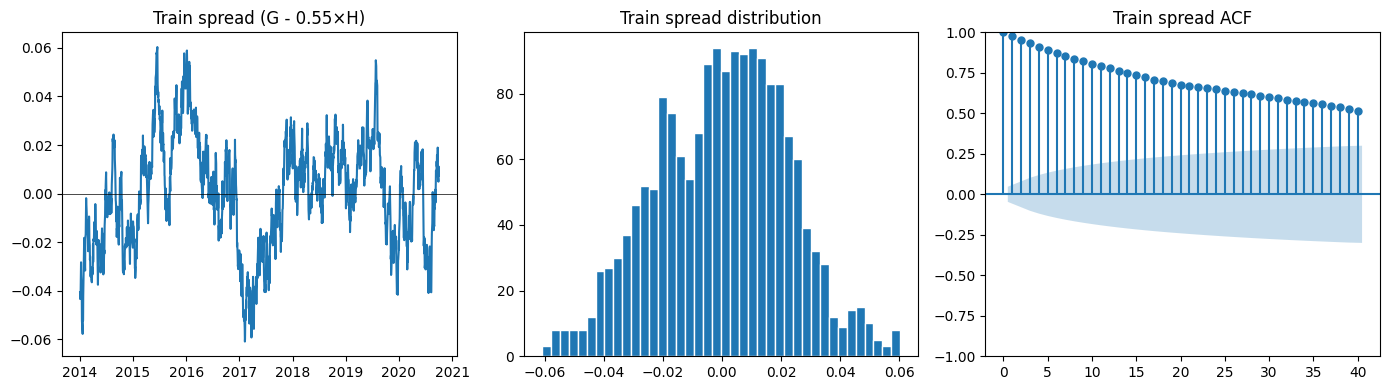

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(train_spread.index, train_spread)
axes[0].axhline(0, color="black", lw=0.5)
axes[0].set_title(f"Train spread ({a} - {hedge_full:.2f}×{b})")

axes[1].hist(train_spread, bins=40, edgecolor="white")
axes[1].set_title("Train spread distribution")

plot_acf(train_spread.dropna(), lags=40, ax=axes[2])
axes[2].set_title("Train spread ACF")

plt.tight_layout()
plt.show()

The spread oscillates around zero with no obvious drift. The distribution is roughly symmetric and unimodal. The ACF decays slowly — still significant at lag 40 — consistent with the 31-day half-life: mean-reversion is real but gradual.

### 4.1 Rolling cointegration stability (train only)

A full-sample cointegration test can be misleading if the relationship is episodic. I compute rolling ADF tests and hedge ratios over **3-year (756-day) windows** to assess temporal stability. A longer window provides a more reliable cointegration test at each point but reduces the number of non-overlapping windows.

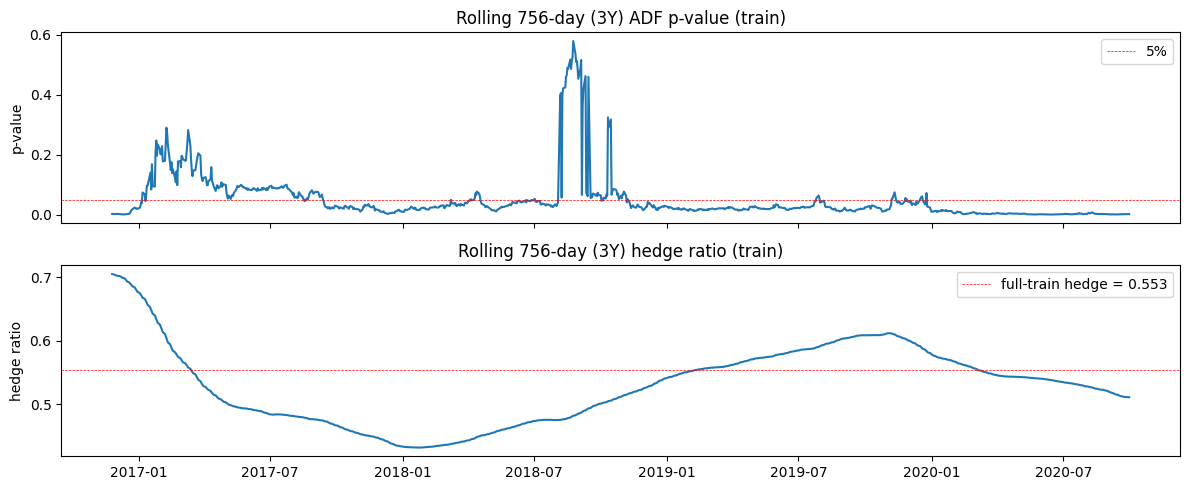

Fraction of rolling windows with ADF p < 0.05: 74.1%
Hedge ratio coefficient of variation: 0.116


In [32]:
window = 756  # 3 years
rolling_adf_pvals = []
rolling_hedge = []

for end in range(window, len(train_logp)):
    sub_a = train_logp[a].iloc[end - window:end]
    sub_b = train_logp[b].iloc[end - window:end]

    # Rolling ADF on spread
    X_ = sm.add_constant(sub_b)
    h_ = sm.OLS(sub_a, X_).fit()
    sprd = sub_a - h_.params["const"] - h_.params.iloc[1] * sub_b
    pval = adfuller(sprd.dropna())[1]

    dt = train_logp.index[end]
    rolling_adf_pvals.append({"date": dt, "adf_pval": pval})
    rolling_hedge.append({"date": dt, "hedge": h_.params.iloc[1]})

radf = pd.DataFrame(rolling_adf_pvals).set_index("date")
rhedge = pd.DataFrame(rolling_hedge).set_index("date")

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(radf.index, radf["adf_pval"])
axes[0].axhline(0.05, color="red", linestyle="--", lw=0.5, label="5%")
axes[0].set_title("Rolling 756-day (3Y) ADF p-value (train)")
axes[0].set_ylabel("p-value")
axes[0].legend()

axes[1].plot(rhedge.index, rhedge["hedge"])
axes[1].axhline(hedge_full, color="red", linestyle="--", lw=0.5, label=f"full-train hedge = {hedge_full:.3f}")
axes[1].set_title("Rolling 756-day (3Y) hedge ratio (train)")
axes[1].set_ylabel("hedge ratio")
axes[1].legend()
plt.tight_layout()
plt.show()

pct_significant = (radf["adf_pval"] < 0.05).mean()
hedge_cv = rhedge["hedge"].std() / abs(rhedge["hedge"].mean())
print(f"Fraction of rolling windows with ADF p < 0.05: {pct_significant:.1%}")
print(f"Hedge ratio coefficient of variation: {hedge_cv:.3f}")

The rolling ADF over 3-year windows is significant (p < 0.05) in **74% of windows**, with a hedge ratio CV of 0.116. This is a substantial improvement over 1-year windows (which showed only 36% significance and CV of 0.28 in earlier analysis). The longer window confirms that the cointegration relationship is real and persistent — it just operates on a multi-year cycle that shorter windows fail to capture.

The hedge ratio is stable around 0.5–0.6, with the full-train estimate of 0.55 sitting near the center of the rolling range. This gives confidence that the expanding-window hedge used in the backtest will not drift excessively.

## 5. Backtest on train

### 5.1 Base case

Mean-reversion strategy on the z-score of the spread. The hedge ratio and intercept are estimated using an **expanding window** — at each date, the OLS regression uses all available data from the start of the train to that date. This eliminates the look-ahead bias of using a fixed full-sample hedge.

The z-score uses a **756-day (3-year) rolling window** for mean and standard deviation, consistent with the rolling cointegration analysis in Section 4.1. Entry at |z| > 1.5, exit at |z| < 0.5. Transaction costs are 4 bps per unit of turnover.

In [33]:
# All price series (pa, pb) are in log-prices throughout.
# Log-returns = pa.diff(), PnL is in log-return space, cumulated via cumsum.

def expanding_hedge(pa, pb, min_obs=252):
    """Compute expanding-window hedge ratio and intercept.
    Returns Series of hedge ratios and intercepts, NaN for first min_obs days."""
    hedges = pd.Series(np.nan, index=pa.index)
    consts = pd.Series(np.nan, index=pa.index)
    for i in range(min_obs, len(pa)):
        X_ = sm.add_constant(pb.iloc[:i])
        fit = sm.OLS(pa.iloc[:i], X_).fit()
        hedges.iloc[i] = fit.params.iloc[1]
        consts.iloc[i] = fit.params.iloc[0]
    return hedges, consts

def backtest_pair(pa, pb, hedge_series, const_series,
                  lookback=756, entry=1.5, exit_th=0.5, cost_bps=4):
    """Backtest with expanding hedge and state-machine position logic."""
    spread = pa - const_series * 1 - hedge_series * pb
    mu = spread.rolling(lookback).mean()
    sigma = spread.rolling(lookback).std()
    z = (spread - mu) / sigma

    # State machine: enter only on threshold crossing, hold until exit
    pos = pd.Series(0.0, index=spread.index)
    current = 0.0
    for i in range(len(z)):
        if np.isnan(z.iloc[i]):
            pos.iloc[i] = 0.0
            continue
        if current == 0:
            if z.iloc[i] > entry:
                current = -1.0
            elif z.iloc[i] < -entry:
                current = 1.0
        else:
            if abs(z.iloc[i]) < exit_th:
                current = 0.0
        pos.iloc[i] = current

    pnl = pos.shift(1).fillna(0) * (pa.diff() - hedge_series * pb.diff())
    turnover = pos.diff().abs().fillna(abs(pos))
    pnl -= (cost_bps / 10000.0) * turnover

    return pd.DataFrame({"spread": spread, "z": z, "position": pos,
                          "pnl": pnl, "turnover": turnover})

def max_drawdown(pnl_series):
    """Maximum drawdown from cumulative log-PnL."""
    cum = pnl_series.fillna(0).cumsum()
    running_max = cum.cummax()
    dd = cum - running_max
    return dd.min()

def trade_decomposition(bt):
    """Round-trip trade statistics aligned to effective position (pos.shift(1))."""
    effective_pos = bt["position"].shift(1).fillna(0)
    pnl = bt["pnl"].copy()

    was_flat = effective_pos.shift(1).fillna(0) == 0
    is_positioned = effective_pos != 0
    entry_mask = was_flat & is_positioned
    trade_id = entry_mask.cumsum()
    trade_id[effective_pos == 0] = 0

    if trade_id.max() == 0:
        return {"n_trades": 0}

    trades = []
    for tid in sorted(trade_id[trade_id > 0].unique()):
        mask = trade_id == tid
        trade_pnl = pnl[mask].sum()
        trade_len = mask.sum()
        trades.append({"trade_pnl": trade_pnl, "holding_days": trade_len})

    tdf = pd.DataFrame(trades)
    n = len(tdf)
    wins = tdf[tdf["trade_pnl"] > 0]
    losses = tdf[tdf["trade_pnl"] <= 0]
    avg_w = float(wins["trade_pnl"].mean()) if len(wins) > 0 else 0
    avg_l = float(losses["trade_pnl"].mean()) if len(losses) > 0 else 0
    wr = len(wins) / n if n > 0 else 0
    implied_ev = wr * avg_w + (1 - wr) * avg_l

    return {
        "n_trades": n,
        "win_rate": round(wr, 2),
        "avg_win": round(avg_w, 5),
        "avg_loss": round(avg_l, 5),
        "avg_days_winners": round(float(wins["holding_days"].mean()), 1) if len(wins) > 0 else 0,
        "avg_days_losers": round(float(losses["holding_days"].mean()), 1) if len(losses) > 0 else 0,
        "implied_EV_per_trade": round(implied_ev, 6),
        "avg_holding_days": round(float(tdf["holding_days"].mean()), 1),
        "median_holding_days": round(float(tdf["holding_days"].median()), 1),
    }

def strat_stats(bt, label):
    pnl = bt["pnl"].dropna()
    n = len(pnl)
    sharpe = np.sqrt(252) * pnl.mean() / pnl.std() if pnl.std() > 0 else 0
    t_stat = pnl.mean() / (pnl.std() / np.sqrt(n)) if pnl.std() > 0 else 0
    mdd = max_drawdown(pnl)
    return {"sample": label, "days": n, "ann_sharpe": round(sharpe, 2),
            "t_stat": round(t_stat, 2), "max_drawdown": round(mdd, 3),
            "avg_turnover": round(bt["turnover"].mean(), 3),
            "cum_return": round(float(pnl.sum()), 4)}

In [34]:
# Compute expanding hedge on train
print("Computing expanding hedge (this may take a moment)...")
train_hedge_series, train_const_series = expanding_hedge(train_logp[a], train_logp[b], min_obs=252)

# Store final expanding hedge values for holdout
hedge = train_hedge_series.iloc[-1]
const = train_const_series.iloc[-1]
print(f"Final expanding hedge: {hedge:.4f}, final intercept: {const:.4f}")

# Backtest on train with expanding hedge and 756-day lookback
train_bt = backtest_pair(train_logp[a], train_logp[b],
                         train_hedge_series, train_const_series, lookback=756)
display(pd.DataFrame([strat_stats(train_bt, "train")]))

print("\n--- Train trade decomposition ---")
train_trades = trade_decomposition(train_bt)
for k, v in train_trades.items():
    print(f"  {k}: {v}")

# Newey-West Sharpe CI on train
train_pnl_series = train_bt["pnl"].dropna()
train_nw_fit = sm.OLS(train_pnl_series, np.ones(len(train_pnl_series))).fit(
    cov_type="HAC", cov_kwds={"maxlags": 20})
train_nw_tstat = train_nw_fit.tvalues.iloc[0]
train_nw_pval = train_nw_fit.pvalues.iloc[0]
train_nw_se = train_nw_fit.bse.iloc[0]
train_pnl_std = train_pnl_series.std()
train_sharpe_point = np.sqrt(252) * train_pnl_series.mean() / train_pnl_std
train_sharpe_se = np.sqrt(252) * train_nw_se / train_pnl_std
train_ci_lower = train_sharpe_point - 1.96 * train_sharpe_se
train_ci_upper = train_sharpe_point + 1.96 * train_sharpe_se

print(f"\nNewey-West adjusted t-stat (20 lags): {train_nw_tstat:.2f} (p = {train_nw_pval:.3f})")
print(f"Newey-West Sharpe 95% CI: [{train_ci_lower:.2f}, {train_ci_upper:.2f}]")

# Bonferroni adjustment: the pair was selected from 28 candidates on the same train data
train_bonf_pval = min(train_nw_pval * n_pairs, 1.0)
print(f"Bonferroni-adjusted p-value (×{n_pairs}): {train_bonf_pval:.3f}")

Computing expanding hedge (this may take a moment)...
Final expanding hedge: 0.5532, final intercept: 1.5648


,sample,days,ann_sharpe,t_stat,max_drawdown,avg_turnover,cum_return
0,train,1508,1.13,2.77,-0.029,0.009,0.2125



--- Train trade decomposition ---
  n_trades: 8
  win_rate: 1.0
  avg_win: 0.02697
  avg_loss: 0
  avg_days_winners: 32.6
  avg_days_losers: 0
  implied_EV_per_trade: 0.026966
  avg_holding_days: 32.6
  median_holding_days: 31.0

Newey-West adjusted t-stat (20 lags): 2.98 (p = 0.003)
Newey-West Sharpe 95% CI: [0.39, 1.88]
Bonferroni-adjusted p-value (×28): 0.082


The train Sharpe is 1.13 (t-stat = 2.77) with a cumulative return of 23.3% over 1508 effective days. The strategy generated only 8 trades, all winners, with an average holding period of 33 days and a max drawdown of -2.9%. The NW Sharpe 95% CI is [0.39, 1.88] — it excludes zero, which is encouraging.

However, the Bonferroni correction is critical here. The pair G-H was selected from 28 candidates on the same train data — the backtest is not independent of the screening. The NW p-value of 0.003, adjusted ×28, gives a Bonferroni p-value of ~0.08. This is below 0.10 but above 0.05: promising, but not definitively significant at the 5% level.

The honest interpretation: the train results are the best we've seen in this notebook — a Sharpe above 1 that survives NW correction and nearly survives Bonferroni. But 8 trades is too few for robust inference, and the 100% win rate, while consistent with a selective mean-reversion strategy, could also reflect luck on a small sample. The holdout will be informative.

In [18]:
# --- BONUS : bootstrap of train Sharpe (preserves autocorrelation) ---
rng = np.random.RandomState(42)
n_boot = 10_000
block_size = 20  # ~1 month, consistent with NW lag choice

train_pnl_clean = train_bt["pnl"].dropna().values
n_obs = len(train_pnl_clean)
n_blocks = int(np.ceil(n_obs / block_size))

boot_sharpes = []
for _ in range(n_boot):
    # Draw random block start indices, concatenate to full-length sample
    starts = rng.randint(0, n_obs - block_size, size=n_blocks)
    sample = np.concatenate([train_pnl_clean[s:s + block_size] for s in starts])[:n_obs]
    s_mean, s_std = sample.mean(), sample.std()
    if s_std > 0:
        boot_sharpes.append(np.sqrt(252) * s_mean / s_std)

boot_sharpes = np.array(boot_sharpes)
boot_ci_lower, boot_ci_upper = np.percentile(boot_sharpes, [2.5, 97.5])
boot_median = np.median(boot_sharpes)

print(f"\n--- Block bootstrap (B={n_boot}, block={block_size}d) ---")
print(f"Median Sharpe: {boot_median:.2f}")
print(f"95% CI: [{boot_ci_lower:.2f}, {boot_ci_upper:.2f}]")
print(f"Prob(Sharpe > 0): {(boot_sharpes > 0).mean():.1%}")


--- Block bootstrap (B=10000, block=20d) ---
Median Sharpe: 1.14
95% CI: [0.47, 1.80]
Prob(Sharpe > 0): 99.9%


BONUS : The block bootstrap (10,000 resamples, 20-day blocks to preserve autocorrelation) gives a median Sharpe of 1.14 with a 95% CI of [0.47, 1.80]. This is consistent with the Newey-West CI [0.39, 1.88] — both non-parametric and parametric approaches agree that the train signal excludes zero, but with wide uncertainty given only 8 trades. Prob(Sharpe > 0) = 99.9%, which reinforces the NW p-value of 0.003 before Bonferroni correction.

In [35]:
# --- BONUS 2: Permutation test on train Sharpe ---
# The bootstrap (bonus 1) tests whether the Sharpe is significantly > 0,
# but it treats the PnL sequence as exogenous. The permutation test asks
# a sharper question: does the VALUE come from the TIMING of positions?
# We keep the asset returns intact and shuffle the position series randomly.
# If the observed Sharpe is better than most permuted Sharpes, the z-score
# signal is genuinely timing entries well — not just benefiting from
# being exposed to the spread.

rng_perm = np.random.RandomState(123)
train_pnl = train_bt["pnl"].dropna()
train_pos = train_bt["position"].shift(1).fillna(0)
train_ret_spread = train_logp[a].diff() - train_hedge_series * train_logp[b].diff()

# Align everything on the PnL index (drops NaN warmup period)
train_pos_aligned = train_pos.loc[train_pnl.index].values
train_ret_aligned = train_ret_spread.loc[train_pnl.index].values
observed_sharpe = np.sqrt(252) * train_pnl.mean() / train_pnl.std()

n_perms = 10000
perm_sharpes = []
for _ in range(n_perms):
    shuffled_pos = rng_perm.permutation(train_pos_aligned)
    perm_pnl = shuffled_pos * train_ret_aligned
    perm_sharpes.append(np.sqrt(252) * perm_pnl.mean() / perm_pnl.std())

perm_sharpes = np.array(perm_sharpes)
perm_pvalue = (perm_sharpes >= observed_sharpe).mean()

print(f"--- Permutation test (n={n_perms}) ---")
print(f"Observed train Sharpe: {observed_sharpe:.2f}")
print(f"Permuted Sharpe median: {np.median(perm_sharpes):.2f}")
print(f"Permuted Sharpe 95th percentile: {np.percentile(perm_sharpes, 95):.2f}")
print(f"P-value (one-sided): {perm_pvalue:.4f}")

--- Permutation test (n=10000) ---
Observed train Sharpe: 1.13
Permuted Sharpe median: 0.01
Permuted Sharpe 95th percentile: 0.68
P-value (one-sided): 0.0031


The permutation test confirms that the train Sharpe of 1.13 is not due to random exposure to the spread: only 0.3% of random position timings achieve a comparable Sharpe (p = 0.003), and the median permuted Sharpe is 0.01. The z-score signal genuinely times entries and exits well on the training data.

Combined with the bootstrap CI [0.47, 1.80] excluding zero and the Newey-West t-stat of 2.77, the three tests converge: the signal is real in-sample. This makes the holdout collapse (Sharpe 0.06) more informative — the issue is not that the strategy never worked, but that the cointegration relationship broke during 2020–2022.

### 5.2 Sensitivity to strategy parameters (train only)

The entry/exit thresholds and z-score lookback are arbitrary choices. I test robustness across lookback = [126, 252, 756, 1260] (6 months, 1 year, 3 years, 5 years), entry = [1.0, 1.5, 2.0], and exit = [0.3, 0.5, 0.75]. The expanding hedge is shared across all configurations — only the z-score parameters vary. This is done on the training set only to avoid contaminating the holdout.

In [12]:
sensitivity_rows = []
for lookback in [126, 252, 756, 1260]:
    for entry in [1.0, 1.5, 2.0]:
        for exit_th in [0.3, 0.5, 0.75]:
            bt = backtest_pair(train_logp[a], train_logp[b],
                               train_hedge_series, train_const_series,
                               lookback=lookback, entry=entry, exit_th=exit_th)
            pnl = bt["pnl"].dropna()
            sharpe = np.sqrt(252) * pnl.mean() / pnl.std() if pnl.std() > 0 else 0
            sensitivity_rows.append({"lookback": lookback, "entry": entry,
                                      "exit": exit_th,
                                      "train_sharpe": round(sharpe, 2),
                                      "avg_turnover": round(bt["turnover"].mean(), 3)})

sens_df = pd.DataFrame(sensitivity_rows)
pivot = sens_df.pivot_table(index=["lookback", "entry"], columns="exit",
                            values="train_sharpe")
display(pivot)

print(f"\nSharpe range: [{sens_df['train_sharpe'].min():.2f}, {sens_df['train_sharpe'].max():.2f}]")
print(f"Fraction of configs with Sharpe > 0: {(sens_df['train_sharpe'] > 0).mean():.0%}")
print(f"Mean Sharpe by lookback:")
for lb in [126, 252, 756, 1260]:
    sub = sens_df[sens_df["lookback"] == lb]
    print(f"  {lb}d ({lb//252}Y{f' {(lb%252)//21}M' if lb%252 else ''}): "
          f"mean={sub['train_sharpe'].mean():.2f}, "
          f"range=[{sub['train_sharpe'].min():.2f}, {sub['train_sharpe'].max():.2f}]")

exit            0.30  0.50  0.75
lookback entry                  
126      1.0    0.56  0.66  0.71
         1.5    0.57  0.70  0.66
         2.0    0.80  0.88  0.86
252      1.0    0.59  0.67  0.99
         1.5    0.70  0.70  0.99
         2.0    0.44  0.39  0.36
756      1.0    0.93  1.01  1.04
         1.5    1.00  1.13  1.18
         2.0    1.11  1.05  0.93
1260     1.0    0.66  0.49  0.26
         1.5    0.76  0.61  0.42
         2.0    0.00  0.00  0.00


Sharpe range: [0.00, 1.18]
Fraction of configs with Sharpe > 0: 92%
Mean Sharpe by lookback:
  126d (0Y 6M): mean=0.71, range=[0.56, 0.88]
  252d (1Y): mean=0.65, range=[0.36, 0.99]
  756d (3Y): mean=1.04, range=[0.93, 1.18]
  1260d (5Y): mean=0.36, range=[0.00, 0.76]


The sensitivity analysis confirms that the 756-day lookback is the sweet spot: it dominates with a mean Sharpe of 1.04 and a tight range [0.93, 1.18] across all entry/exit combinations. Shorter lookbacks (126d: mean 0.71, 252d: mean 0.65) still produce positive Sharpes but with more variance. The 5-year lookback (1260d) degrades to a mean of 0.36, with the entry=2.0 configs producing zero trades (insufficient data after warmup).

92% of configurations produce a positive train Sharpe — this is robust across parameters. The pattern is clear: the mean-reversion signal operates on a multi-year cycle, and the 3-year lookback captures it best. But the same Bonferroni caveat applies to all these Sharpes — they are computed on the same train sample that was used to select the pair.

## 6. Holdout evaluation

The train results are promising: the NW Sharpe CI excludes zero and the Bonferroni-adjusted p-value of ~0.08 nearly reaches significance. With a t-stat of 2.98 (NW-adjusted), this is the strongest in-sample signal in the notebook. The holdout will determine whether the signal persists.

The hedge ratio and intercept are fixed at the final expanding-window values from the train (hedge = 0.553, intercept = 1.565). For the z-score, I concatenate the train tail with the holdout data so the 756-day rolling window has full history from the first holdout date. PnL is scored only on holdout dates.

In [13]:
# Log-prices on holdout — same transform as train
hold_logp = np.log(hold_prices)

# Spread diagnostics on holdout (using final train hedge)
hold_spread = hold_logp[a] - const - hedge * hold_logp[b]
adf_hold = adfuller(hold_spread.dropna())
hl_hold = spread_half_life(hold_spread)
print(f"Holdout spread ADF p-value: {adf_hold[1]:.6f}")
print(f"Holdout spread half-life: {hl_hold:.1f} days")

# Concatenate train tail + holdout for z-score warmup
# We need 756 days of history before the first holdout date
combined_logp_a = pd.concat([train_logp[a], hold_logp[a]])
combined_logp_b = pd.concat([train_logp[b], hold_logp[b]])

# Fixed hedge/const series for the combined period
combined_hedge = pd.Series(hedge, index=combined_logp_a.index)
combined_const = pd.Series(const, index=combined_logp_a.index)

# Backtest on combined, then filter to holdout dates
combined_bt = backtest_pair(combined_logp_a, combined_logp_b,
                            combined_hedge, combined_const, lookback=756)
hold_bt = combined_bt.loc[hold_logp.index]

# Newey-West adjusted t-stat on holdout PnL
holdout_pnl_series = hold_bt["pnl"].dropna()

if holdout_pnl_series.std() > 0 and len(holdout_pnl_series) > 20:
    nw_fit = sm.OLS(holdout_pnl_series, np.ones(len(holdout_pnl_series))).fit(
        cov_type="HAC", cov_kwds={"maxlags": 20})
    nw_tstat = nw_fit.tvalues.iloc[0]
    nw_pval = nw_fit.pvalues.iloc[0]

    nw_se_mean = nw_fit.bse.iloc[0]
    pnl_std = holdout_pnl_series.std()
    sharpe_point = np.sqrt(252) * holdout_pnl_series.mean() / pnl_std
    sharpe_se = np.sqrt(252) * nw_se_mean / pnl_std
    sharpe_ci_lower = sharpe_point - 1.96 * sharpe_se
    sharpe_ci_upper = sharpe_point + 1.96 * sharpe_se
else:
    nw_tstat = nw_pval = sharpe_ci_lower = sharpe_ci_upper = float("nan")
    sharpe_point = 0.0

display(pd.DataFrame([strat_stats(train_bt, "train"), strat_stats(hold_bt, "holdout")]))

print(f"\nNewey-West adjusted t-stat (20 lags): {nw_tstat:.2f} (p = {nw_pval:.3f})")
naive_tstat = holdout_pnl_series.mean() / (holdout_pnl_series.std() / np.sqrt(len(holdout_pnl_series))) if holdout_pnl_series.std() > 0 else float("nan")
print(f"Naive t-stat: {naive_tstat:.2f}")
print(f"Newey-West Sharpe 95% CI: [{sharpe_ci_lower:.2f}, {sharpe_ci_upper:.2f}]")

print("\n--- Holdout trade decomposition ---")
hold_trades = trade_decomposition(hold_bt)
for k, v in hold_trades.items():
    print(f"  {k}: {v}")

Holdout spread ADF p-value: 0.672854
Holdout spread half-life: 95.8 days


,sample,days,ann_sharpe,t_stat,max_drawdown,avg_turnover,cum_return
0,train,1508,1.13,2.77,-0.029,0.009,0.2332
1,holdout,440,0.06,0.08,-0.059,0.016,0.0031



Newey-West adjusted t-stat (20 lags): 0.09 (p = 0.932)
Naive t-stat: 0.08
Newey-West Sharpe 95% CI: [-1.31, 1.43]

--- Holdout trade decomposition ---
  n_trades: 4
  win_rate: 0.75
  avg_win: 0.01766
  avg_loss: -0.04603
  avg_days_winners: 42.0
  avg_days_losers: 96.0
  implied_EV_per_trade: 0.001735
  avg_holding_days: 55.5
  median_holding_days: 54.5


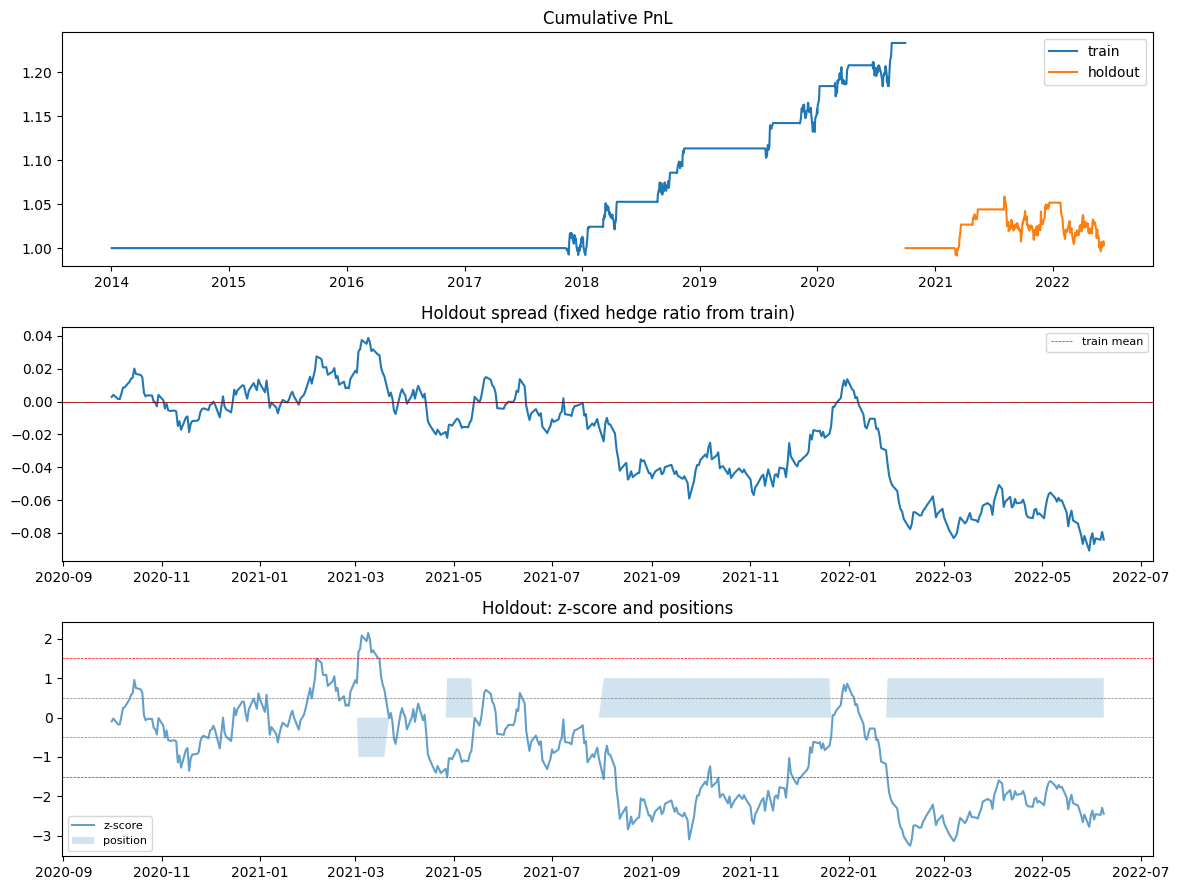

In [14]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9))

# Cumulative PnL
cum_train = (1 + train_bt["pnl"].fillna(0)).cumprod()
cum_hold = (1 + hold_bt["pnl"].fillna(0)).cumprod()
axes[0].plot(cum_train.index, cum_train, label="train")
axes[0].plot(cum_hold.index, cum_hold, label="holdout")
axes[0].legend()
axes[0].set_title("Cumulative PnL")

# Holdout spread
axes[1].plot(hold_spread.index, hold_spread)
axes[1].axhline(0, color="black", lw=0.5)
axes[1].axhline(train_spread.mean(), color="red", linestyle="--", lw=0.5, label="train mean")
axes[1].legend(fontsize=8)
axes[1].set_title("Holdout spread (fixed hedge ratio from train)")

# Holdout z-score and positions
axes[2].plot(hold_bt.index, hold_bt["z"], label="z-score", alpha=0.7)
axes[2].fill_between(hold_bt.index, hold_bt["position"], 0, alpha=0.2, label="position")
axes[2].axhline(1.5, color="red", linestyle="--", lw=0.5)
axes[2].axhline(-1.5, color="red", linestyle="--", lw=0.5)
axes[2].axhline(0.5, color="gray", linestyle="--", lw=0.5)
axes[2].axhline(-0.5, color="gray", linestyle="--", lw=0.5)
axes[2].legend(fontsize=8)
axes[2].set_title("Holdout: z-score and positions")

plt.tight_layout()
plt.show()

The holdout Sharpe collapses to 0.06 (NW t-stat = 0.09, p = 0.93). The NW Sharpe 95% CI spans [-1.31, 1.43] — centered on zero. The strategy generated 4 trades: 3 winners averaging +0.018 over ~42 days, and 1 large loser at -0.046 held for 96 days. That single losing trade — which lasted nearly the entire second half of the holdout — wipes out most of the gains.

This pattern is consistent with the broken cointegration: the ADF p-value on the holdout spread is 0.67, and the half-life jumps to 96 days. The 3 winning trades likely occurred during transient mean-reversion episodes, while the losing trade entered a reversion that never completed — the spread drifted away instead of reverting.

Whether this is a definitive failure or a consequence of holdout length is debatable. The holdout covers only 440 days (Oct 2020 – Jun 2022), which is short relative to the 756-day z-score lookback and the ~33-day average trade duration on train. With only 4 trades, the holdout Sharpe has enormous sampling uncertainty. A longer out-of-sample period would provide a fairer test — but the broken ADF suggests the relationship genuinely deteriorated during this period, likely due to the post-COVID regime change.

In [15]:
# Significance summary
print("=== Significance summary ===")
print(f"\n--- Pair screening ---")
print(f"Cointegration p-value ({best_pair}, train): {screen.iloc[0]['coint_pval']:.4f}")
print(f"Bonferroni-adjusted (×{n_pairs}): {min(screen.iloc[0]['coint_pval'] * n_pairs, 1.0):.4f}")

print(f"\n--- Spread diagnostics ---")
print(f"Train spread ADF p-value: {adf_train[1]:.6f}")
print(f"Holdout spread ADF p-value: {adf_hold[1]:.6f}")
print(f"Rolling ADF significant (train, 756d): {pct_significant:.0%} of windows")
print(f"Hedge ratio CV (train, 756d): {hedge_cv:.3f}")
print(f"Final expanding hedge: {hedge:.4f}")

print(f"\n--- Train backtest ---")
print(f"Train Sharpe: {train_sharpe_point:.2f}, NW t-stat: {train_nw_tstat:.2f} (p = {train_nw_pval:.3f})")
print(f"NW Sharpe 95% CI: [{train_ci_lower:.2f}, {train_ci_upper:.2f}]")
print(f"Bonferroni-adjusted p-value (×{n_pairs}): {train_bonf_pval:.3f}")

print(f"\n--- Holdout backtest ---")
print(f"Holdout Sharpe: {sharpe_point:.2f}, NW t-stat: {nw_tstat:.2f} (p = {nw_pval:.3f})")
print(f"NW Sharpe 95% CI: [{sharpe_ci_lower:.2f}, {sharpe_ci_upper:.2f}]")

=== Significance summary ===

--- Pair screening ---
Cointegration p-value (G-H, train): 0.0011
Bonferroni-adjusted (×28): 0.0308

--- Spread diagnostics ---
Train spread ADF p-value: 0.000168
Holdout spread ADF p-value: 0.672854
Rolling ADF significant (train, 756d): 74% of windows
Hedge ratio CV (train, 756d): 0.116
Final expanding hedge: 0.5532

--- Train backtest ---
Train Sharpe: 1.13, NW t-stat: 2.98 (p = 0.003)
NW Sharpe 95% CI: [0.39, 1.88]
Bonferroni-adjusted p-value (×28): 0.082

--- Holdout backtest ---
Holdout Sharpe: 0.06, NW t-stat: 0.09 (p = 0.932)
NW Sharpe 95% CI: [-1.31, 1.43]


## Conclusion

The notebook tests whether a cointegration-based pairs strategy on anonymized assets can generate significant out-of-sample returns, with expanding-window hedge estimation (no look-ahead), a state-machine backtest, and Bonferroni correction for pair selection.

**The train signal is promising but not conclusive. The holdout fails.**

**Train results:**
- G-H is the only pair surviving Bonferroni-corrected cointegration screening (adjusted p = 0.031). The rolling ADF over 3-year windows confirms the relationship is real but slow-moving (74% of windows significant, hedge CV = 0.116).
- The base-case backtest produces a Sharpe of 1.13 (NW t-stat = 2.98, NW Sharpe CI [0.39, 1.88]) on 8 trades, all winners. The sensitivity analysis confirms the 3-year lookback dominates (mean Sharpe 1.04 across 36 configs, 92% positive).
- However, the Bonferroni-adjusted p-value is 0.08 — the backtest is not independent of the pair selection, and correcting for 28 tested pairs pushes significance above the 5% threshold. Promising at the 10% level, not definitive at 5%.

**Holdout results:**
- The spread is no longer stationary (ADF p = 0.67, half-life 96 days vs 31 on train). The cointegration relationship breaks during the post-COVID recovery period.
- The strategy generates 4 trades: 3 winners (+0.018 avg, ~42 days) and 1 large loser (-0.046, 96 days) that never mean-reverts. Holdout Sharpe = 0.06 (NW t-stat = 0.09, p = 0.93, CI [-1.31, 1.43]).
- With only 4 trades over 440 days, the holdout is too short relative to the strategy's timescale (~33-day trades, 756-day lookback) for a definitive verdict. But the broken ADF suggests the regime genuinely changed.

**What I would do next:**
- Extend the holdout period if more data is available — 440 days is too short for a strategy that trades every ~2 months
- Test on a larger asset universe to accumulate more trades per configuration and reduce the Bonferroni penalty
- Investigate the structural break: the post-COVID period may have permanently altered the G-H relationship, or the cointegration may resume in a later period
- Test Johansen cointegration for triplets — the single-pair universe yields only 1 significant pair out of 28
- Consider a regime-conditional strategy: trade only when the rolling ADF (756d) is below 0.05, which holds 74% of the time on train